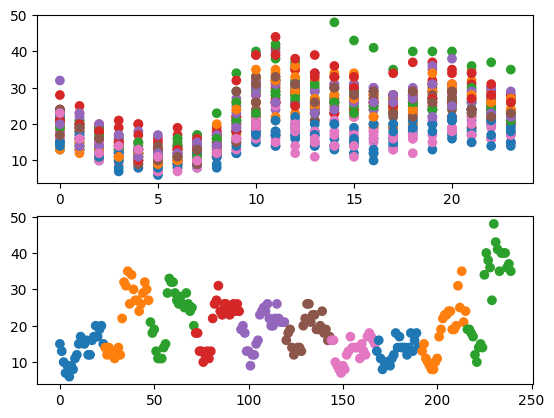

In [45]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.fft import fft, fftfreq, irfft

traffic_data = pd.read_csv("C:\\Users\\Bachs\\OneDrive\\Desktop\\Phys375_Assignment1_Files\\Midterm\\traffic.csv",header = 0, names =["dates", "junction", "vehicleAmt", "id"])
#print(traffic_data["dates"][0:24])
#print("AAA")
#print(traffic_data["dates"][24:25])
colors = [
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
    '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf',
    '#aec7e8', '#ffbb78', '#98df8a', '#ff9896', '#c5b0d5',
    '#c49c94', '#f7b6d2', '#c7c7c7', '#dbdb8d', '#9edae5',
    '#ad494a', '#8c6d31', '#e7ba52', '#636363'
]
fig1, ax1 = plt.subplots(2,1)

ax1[0].scatter([x%24 for x in range(0,1000)], traffic_data["vehicleAmt"][0:1000], color = [colors[(x//24)%7] for x in range(0,1000)])
ax1[1].scatter(range(240), traffic_data["vehicleAmt"][0:240], color = [colors[(x//24)%7] for x in range(0,240)])

#There's so much overlapping data the colors aren't all that useful!


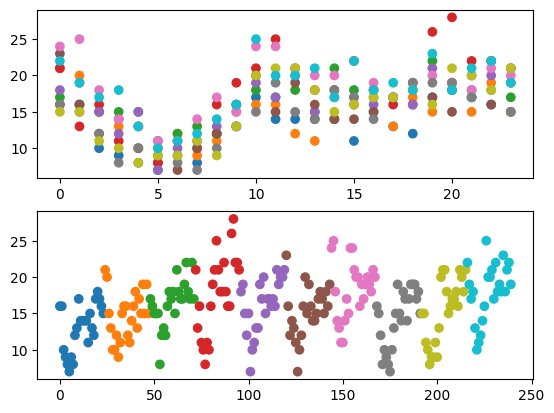

In [46]:
weekSep = [[],[],[],[],[],[],[]]
for i in range(10001):
    #print((i%168)//24%7)
    weekSep[((i%168)//24)%7].append(traffic_data["vehicleAmt"][i])
#print(weekSep[1])
#print(traffic_data["vehicleAmt"][24:48])
fig2, ax2 = plt.subplots(2,1)
ax2[0].scatter([x%24 for x in range(0,240)], weekSep[6][0:240], color = [colors[(x//24)%10] for x in range(0,240)])
ax2[1].scatter(range(0,240), weekSep[6][0:240], color = [colors[(x//24)%10] for x in range(0,240)])
#print(1000/24)

168


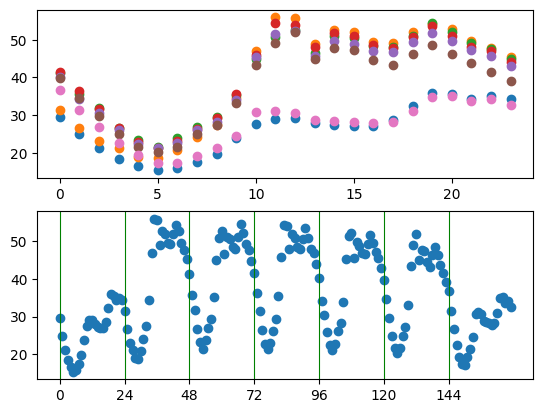

In [47]:
week_hourly_averages = []
fig3, ax3 = plt.subplots(2,1)

for i in range(7):
    hourly_avgs = [0]*24
    for j in range(len(weekSep[i])):
        hourly_avgs[j%24]+=weekSep[i][j]
    hourly_avgs = [x/(len(weekSep[i])/24) for x in hourly_avgs]
    week_hourly_averages.append(hourly_avgs)
    ax3[0].scatter(range(24),week_hourly_averages[i])

flattened_week_avgs = sum(week_hourly_averages, [])
print(len(flattened_week_avgs))
plt.scatter(range(168),flattened_week_avgs)
ax3[1].set_xticks(np.arange(0,168,24), minor = False)
ax3[1].grid(which="major",axis="x",color="green")

In [ ]:
#THIS FUNCTION WAS NOT FULLY WRITTEN BY ME! 
#ChatGPT did most of it.
def fft_to_desmos_formula(x, fs, threshold=0.01, max_terms=20):
    """
    Converts a real-valued signal into a sum-of-cosines formula from its FFT.

    Parameters:
        x (array): Real-valued input signal
        fs (float): Sampling rate in Hz
        threshold (float): Minimum amplitude to include a term
        max_terms (int): Max number of terms to print
    """
    terms = []
    N = len(x)
    X = np.fft.rfft(x)
    freqs = np.fft.rfftfreq(N, d=1/fs)

    formula_terms = []
    for k in range(len(X)):
        amplitude = 2 * np.abs(X[k]) / N
        phase = np.angle(X[k])
        freq = freqs[k]

        # Correct for DC and Nyquist term (no factor of 2)
        if k == 0 or (N % 2 == 0 and k == N // 2):
            amplitude /= 2

        if amplitude >= threshold:
            a = round(amplitude, 4)
            f = round(freq, 4)
            p = round(phase, 4)
            term = f"{a} * cos(2π * {f} * x + {p})"
            formula_terms.append((amplitude, term))
            terms.append([float(a),float(f),float(p)])

    # Sort by descending amplitude and print
    formula_terms.sort(reverse=True)
    #print(formula_terms)
    print("x(t) ≈ " + " +\n       ".join([t[1] for t in formula_terms[:max_terms]]))
    terms.sort(reverse=True)
    print(terms[:20])
    for x in range(0,20):
        print((x+1),",",terms[x][0],terms[x][1],terms[x][2])

fft_to_desmos_formula(flattened_week_avgs,1 )

x(t) ≈ 36.4114 * cos(2π * 0.0 * x + 0.0) +
       11.943 * cos(2π * 0.0417 * x + 1.868) +
       7.4559 * cos(2π * 0.006 * x + -3.1081) +
       5.3972 * cos(2π * 0.0833 * x + 0.6213) +
       4.0929 * cos(2π * 0.0119 * x + 2.8736) +
       2.4383 * cos(2π * 0.0357 * x + -0.9627) +
       2.25 * cos(2π * 0.0298 * x + -0.6945) +
       1.6637 * cos(2π * 0.0476 * x + -0.8393) +
       1.6334 * cos(2π * 0.125 * x + -2.4224) +
       1.4759 * cos(2π * 0.0179 * x + 2.357) +
       1.3779 * cos(2π * 0.0238 * x + -0.023) +
       1.2712 * cos(2π * 0.25 * x + 1.7061) +
       0.8968 * cos(2π * 0.2083 * x + -1.0232) +
       0.8196 * cos(2π * 0.0536 * x + -0.6649) +
       0.727 * cos(2π * 0.1667 * x + 0.4631) +
       0.596 * cos(2π * 0.0774 * x + 2.8986) +
       0.5288 * cos(2π * 0.0595 * x + -0.6963) +
       0.5254 * cos(2π * 0.0714 * x + 2.7455) +
       0.4042 * cos(2π * 0.4167 * x + 0.2493) +
       0.3615 * cos(2π * 0.0655 * x + 2.9982)
[[36.4114, 0.0, 0.0], [11.943, 0.0417, 1.868], [7

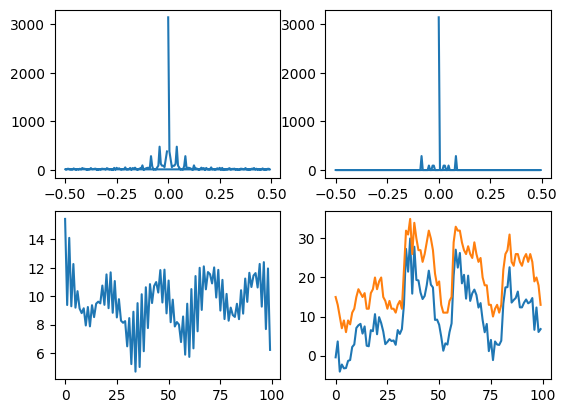

In [49]:
fig4a, ax4a = plt.subplots(2,2)
N1 = 24*7
T1 = 1.0
freqs1 = fftfreq(N1,T1)
fft_values1 = fft(traffic_data["vehicleAmt"][0:24*7])
#print(np.abs(fft_values))
#print(freqs)
ax4a[0][0].plot(freqs1, np.abs(fft_values1))
#Denoise:
denoised_fft1 = fft_values1.copy()
for i, f in enumerate(fft_values1):
    if (f<50):
        denoised_fft1[i] = 0
ax4a[0][1].plot(freqs1, np.abs(denoised_fft1))
reversed_signal = irfft(denoised_fft1)

num_weeks = len(traffic_data["vehicleAmt"])//N1
weekly_pattern_full = np.tile(reversed_signal,num_weeks)
weekly_pattern_full = weekly_pattern_full[:len(traffic_data["vehicleAmt"])]

#print(denoised_fft1)

adjusted_vehicleAmt = traffic_data["vehicleAmt"]-weekly_pattern_full
ax4a[1][0].plot(weekly_pattern_full[0:100])
ax4a[1][1].plot(adjusted_vehicleAmt[0:100])
ax4a[1][1].plot(traffic_data["vehicleAmt"][0:100])

In [50]:
length = 24*7
fs = 1
frequencies = np.fft.fftfreq(length,d=1/fs)
#print(frequencies)
num_terms = 167
for k in range(1, num_terms + 1):
    A = 2 * np.abs(denoised_fft1[k]) / fs
    if (A>0.0001):
        phi = np.angle(denoised_fft1[k])
        freq = frequencies[k]
        print(f"{A:.5f} * cos(2π * {freq:.2f} * t + {phi:.2f})")

181.59082 * cos(2π * 0.02 * t + -0.24)
181.74282 * cos(2π * 0.03 * t + 0.08)
185.70719 * cos(2π * 0.05 * t + -0.14)
575.06612 * cos(2π * 0.08 * t + 0.62)
575.06612 * cos(2π * -0.08 * t + -0.62)
185.70719 * cos(2π * -0.05 * t + 0.14)
181.74282 * cos(2π * -0.03 * t + -0.08)
181.59082 * cos(2π * -0.02 * t + 0.24)


11/1/2015 0:00
6/30/2017 23:00


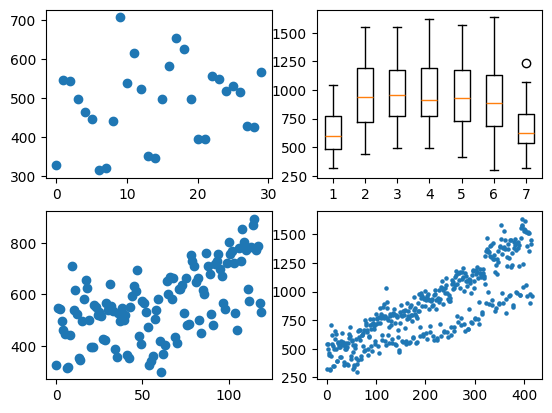

In [51]:
daily_totals = [0]
fig4, ax4 = plt.subplots(2,2)
index = 0
for i in range(10001):
    if (index==i//24):
        daily_totals[index]+=traffic_data["vehicleAmt"][i]
    else:
        #print(traffic_data["dates"][i])
        daily_totals.append(traffic_data["vehicleAmt"][i])
        index+=1
        #print("index:",index)
#print(daily_totals)
#print(49//24)
#print(len(daily_totals))
ax4[0][0].scatter(range(30), daily_totals[0:30])
#ax4[0][1].scatter([x%7+1 for x in range(417)], daily_totals)
#I want to make a boxplot for this instead!
week_broken = [[],[],[],[],[],[],[]]
for x in range(417):
    week_broken[x%7].append(daily_totals[x])
ax4[0][1].boxplot(week_broken)

ax4[1][0].scatter(range(120), daily_totals[0:120])
ax4[1][1].scatter(range(417), daily_totals, s=5)
print(traffic_data["dates"][0])
print(traffic_data["dates"][14591])

#Something to note: It's possible that the variation itself is also continually changing! 
#How could we check for this? How could we represent it?
#AND: I think it'd be cool to represent each day of the week on its own graph... Potential for 7-channel audio or something!

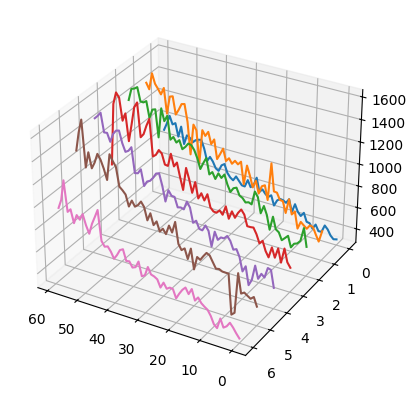

In [52]:
#Separating it out by day of the week!
fig4c = plt.figure()
ax4c = fig4c.add_subplot(111,projection='3d')
#ax4c.view_init(10, 20,15)

for i in range(7):
    ax4c.plot(range(len(week_broken[i])),week_broken[i],i,zdir='y')
ax4c.view_init(30, 120,0)

#Can't really find a helpful angle.

87
129
106
57
80
72
109
95
96
101
86
99
100
93
101
123
119
157
88
118
116
135
114
125
115
134
138
134
145
139
128
170
143
179
181
133
185
185
175
194
202
168
179
186
181
138
199
203
210
181
235
235
206
204
219
190
223
228


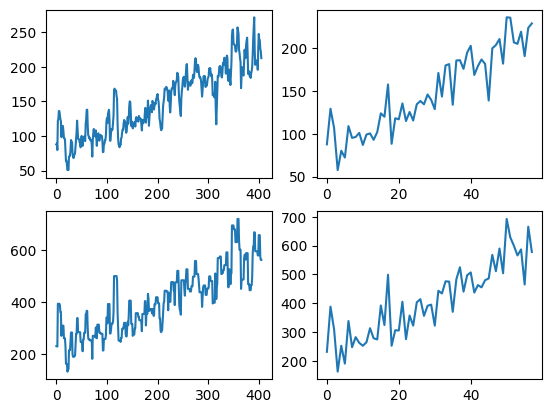

In [ ]:
#Here, I want to get weekly standard deviation data!
figSd, axSd = plt.subplots(2,2)
overlapping_weekly_sd = []
overlapping_weekly_minMax = []
weekly_sd = []
weekly_minMax = []
for i in range(len(daily_totals)-len(daily_totals)%7-7):
    overlapping_weekly_sd.append(np.std(daily_totals[i:i+7]))
    overlapping_weekly_minMax.append(np.max(daily_totals[i:i+7])-np.min(daily_totals[i:i+7]))
    if(i%7==0):
        weekly_sd.append(np.std(daily_totals[i:i+7]))
        weekly_minMax.append(np.max(daily_totals[i:i+7])-np.min(daily_totals[i:i+7]))


axSd[0][0].plot(overlapping_weekly_sd)
axSd[0][1].plot(weekly_sd)
#Unsurprisingly, the weekly max-min values follow the shape of the Standard deviations very well.
axSd[1][0].plot(overlapping_weekly_minMax)
axSd[1][1].plot(weekly_minMax)



3076
10017


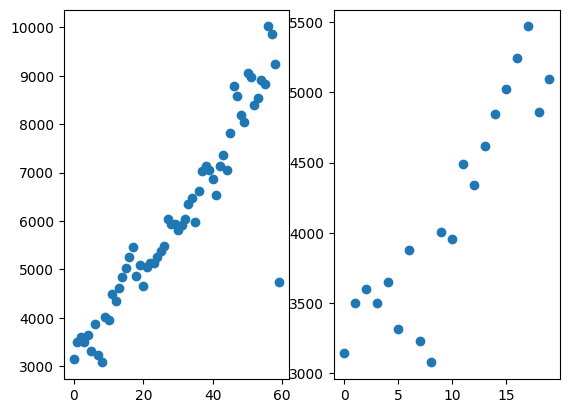

In [67]:
fig5, ax5 = plt.subplots(1,2)
weekly_totals = [0]
index = 0
for i in range(len(daily_totals)):
    if(i//7==index):
        weekly_totals[index]+=daily_totals[i]
    else:
        index+=1
        weekly_totals.append(daily_totals[i])


ax5[0].scatter(range(len(weekly_totals)), weekly_totals)
ax5[1].scatter(range(20), weekly_totals[0:20])

#for x in weekly_totals:
#    print(int(x))
print(min(weekly_totals))
print(max(weekly_totals))
f = open("weekly_info.txt","w")

for c,a,b in zip(range(len(weekly_sd)), weekly_sd,weekly_totals):
    f.write(f"{c+1}, {a} {b};\n")
f.close()

[ 7.00679672 12.58294414  6.12044131 ... 12.5790774   2.7599535
 12.58075478]


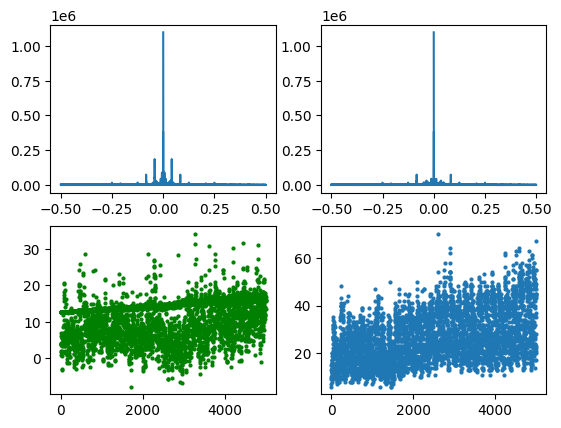

In [55]:
#Now it's time for coolness!
fig6, ax6 = plt.subplots(2,2)
N = len(traffic_data["vehicleAmt"])
T = 1.0
freqs = fftfreq(N,T)
fft_values = fft(traffic_data["vehicleAmt"])
#print(np.abs(fft_values))
#print(freqs)
ax6[0][0].plot(freqs, np.abs(fft_values))
#There's DEFINITELY a periodicity here! 

#The next 4 lines were made possible by ChatGPT, but I've made sure that I understand it!
filtered_fft = fft_values.copy()
for i, f in enumerate(freqs):
    if (np.isclose(abs(f), [1/24, 1/168], atol=0.001).any()): 
        filtered_fft[i] = 0

ax6[0][1].plot(freqs, abs(filtered_fft))

new_signal = irfft(filtered_fft)
print(new_signal)

ax6[1][0].scatter(range(5000), new_signal[0:5000],s=4, color = "green")
ax6[1][1].scatter(range(5000), traffic_data["vehicleAmt"][0:5000], s = 4)
#ax6[1][1].scatter(range(32), (removed_noise[0:32]),s=4, color = "green")

#Granted.... The FFT didn't go as planned.... 
#BUT... It's still kinda cool. 

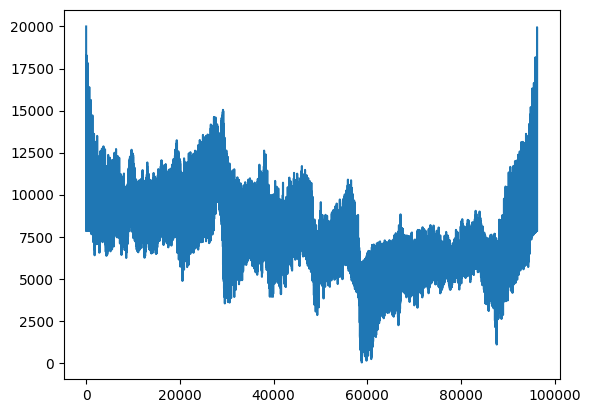

In [56]:
#Now for more witchcraft! Sonification.

from scipy.io.wavfile import write
#BIT_RATE = 16
SAMPLING_RATE = 48000
#MAX_AMP = (2**BIT_RATE/2)-1
import sounddevice as sd

denoised_fft = fft_values.copy()
for i, f in enumerate(fft_values):
    if (f<10000):
        denoised_fft[i] = 0
#plt.plot(denoised_fft)

denoised_signal = irfft(denoised_fft)


#f = open("file2.txt","a")

#plt.plot(denoised_signal)
scaled_signal = []
min_guy = min(denoised_signal)
max_guy = max(denoised_signal)
for i in denoised_signal:
    scaled_signal.append((i-min_guy)*(20000-20)/(max_guy-min_guy)+20)

normalized = np.int16(scaled_signal/np.max(np.abs(scaled_signal)) * 32767)

plt.plot(scaled_signal)

for i in traffic_data["vehicleAmt"][0:10]:
    sd.play(normalized, SAMPLING_RATE*i/10)
    sd.wait(0.001)


#The language I wanted to use for audio processing is called Max/MSP. It has so many cool features for working with sound!
#But unfortunately, I used up my free trial of it (I used it for a project last semester)
#Special thanks to: https://capital-g.github.io/musikinformatik-sose2021/01_spect_resynth/canvas.html
#And to: https://labex.io/tutorials/python-how-to-convert-a-number-from-one-range-to-another-in-python-397959
#For the audio processing stuff. 
# I had much more ambitious goals for the audio, but this is good enough for now. 
